# XAI for Battery Degradation — SHAP Analysis on XGBoost

## Objective
Apply **SHAP (SHapley Additive exPlanations)** to explain XGBoost predictions 
of battery **Remaining Useful Life (RUL)** on the HUST and MATR-1 datasets.

## What is SHAP?
SHAP values tell us **how much each feature contributed** to a specific prediction.
- Positive SHAP → pushes prediction higher (longer life)
- Negative SHAP → pushes prediction lower (shorter life)

## Notebook Structure
1. Setup & Data Loading
2. Feature Extraction (9 interpretable electrochemical features)
3. Train XGBoost Model
4. SHAP Analysis — Global (Beeswarm Plot)
5. SHAP Analysis — Local (Force Plot for individual cells)
6. SHAP Dependence Plots (top features)
7. Electrochemical Interpretation

## 1. Setup


In [28]:
# --- Install Dependencies ---
!pip install -q shap xgboost scikit-learn scipy numba matplotlib pandas numpy

In [29]:
# --- Import Libraries ---
import os, gc, pickle, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import xgboost as xgb
import shap
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from numba import njit

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# Enable SHAP JS visualizations in notebook
shap.initjs()

print("All imports successful!")
print(f"SHAP version: {shap.__version__}")

All imports successful!
SHAP version: 0.50.0


In [30]:
# --- Kaggle Dataset Paths ---
HUST_PATH = Path('/kaggle/input/datasets/nikhilrajiv12/battery-degradation-dataset-xai/HUST')
MATR_PATH = Path('/kaggle/input/datasets/nikhilrajiv12/battery-degradation-dataset-xai/MATR')

for p in [HUST_PATH, MATR_PATH]:
    assert p.exists(), f"Path not found: {p}"
    print(f"{p.name}: {len(list(p.glob('*.pkl')))} cells")

HUST: 77 cells
MATR: 180 cells


## 2. Data Classes


In [31]:
# --- Battery Data Classes (minimal, from BatteryML) ---

class CycleData:
    def __init__(self, cycle_number, *, voltage_in_V=None, current_in_A=None,
                 charge_capacity_in_Ah=None, discharge_capacity_in_Ah=None,
                 time_in_s=None, temperature_in_C=None,
                 internal_resistance_in_ohm=None, **kwargs):
        self.cycle_number = cycle_number
        self.voltage_in_V = voltage_in_V
        self.current_in_A = current_in_A
        self.charge_capacity_in_Ah = charge_capacity_in_Ah
        self.discharge_capacity_in_Ah = discharge_capacity_in_Ah
        self.time_in_s = time_in_s
        self.temperature_in_C = temperature_in_C
        self.internal_resistance_in_ohm = internal_resistance_in_ohm
        self.additional_data = dict(kwargs)

class CyclingProtocol:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)

class BatteryData:
    def __init__(self, cell_id, *, cycle_data=None, max_voltage_limit_in_V=None,
                 min_voltage_limit_in_V=None, charge_protocol=None,
                 discharge_protocol=None, **kwargs):
        self.cell_id = cell_id
        self.cycle_data = cycle_data or []
        self.max_voltage_limit_in_V = max_voltage_limit_in_V
        self.min_voltage_limit_in_V = min_voltage_limit_in_V
        self.charge_protocol = charge_protocol or []
        self.discharge_protocol = discharge_protocol or []
        for k, v in kwargs.items():
            setattr(self, k, v)

    @staticmethod
    def load(filepath):
        with open(filepath, 'rb') as f:
            raw = pickle.load(f)
        if raw.get('charge_protocol'):
            raw['charge_protocol'] = [CyclingProtocol(**p) for p in raw['charge_protocol']]
        if raw.get('discharge_protocol'):
            raw['discharge_protocol'] = [CyclingProtocol(**p) for p in raw['discharge_protocol']]
        raw['cycle_data'] = [CycleData(**d) for d in raw['cycle_data']]
        return BatteryData(**raw)

print("Data classes defined.")

Data classes defined.


## 3. Feature Extraction (Severson Features)

We extract **9 interpretable electrochemical features** from each battery cell.

| Feature | Electrochemical Meaning |
|---------|------------------------|
| DeltaQ_Variance | How much the discharge curve shape changed (cycle 10→100) |
| DeltaQ_Minimum | Largest capacity loss at any voltage point |
| Capacity_Fade_Slope | Rate of capacity degradation over early cycles |
| Capacity_Fade_Intercept | Starting capacity level from linear fit |
| Early_Discharge_Capacity | Capacity at the very first cycle |
| Avg_Charge_Time | How long early cycles take to charge |
| Temperature_Integral | Cumulative thermal stress |
| Min_Internal_Resistance | Lowest measured resistance (health indicator) |
| IR_Change | How much internal resistance increased |


In [32]:
# --- Helper Functions ---

def interpolate_discharge_curve(voltage, capacity, num_points=1000, v_min=0, v_max=1):
    if len(voltage) <= 2:
        return np.zeros(num_points)
    return interp1d(voltage, capacity, bounds_error=False)(np.linspace(v_min, v_max, num_points))

def compute_Qdlin(cell, cycle, use_precalculated=False):
    if 'Qdlin' in cycle.additional_data and use_precalculated:
        return np.array(cycle.additional_data['Qdlin'])
    current = np.array(cycle.current_in_A)
    voltage = np.array(cycle.voltage_in_V)
    capacity = np.array(cycle.discharge_capacity_in_Ah)
    mask = current < -0.1
    qdlin = interpolate_discharge_curve(voltage[mask], capacity[mask], 1000,
                                         v_min=cell.min_voltage_limit_in_V,
                                         v_max=cell.max_voltage_limit_in_V)
    return qdlin[::-1]

@njit
def median_smooth(x, window_size=10):
    result = np.empty_like(x)
    for i in range(len(x)):
        lo, hi = max(0, i-window_size), min(len(x), i+window_size+1)
        result[i] = np.median(x[lo:hi])
    return result

@njit
def compute_charge_time(current, time):
    total = 0.0
    for i in range(1, len(current)):
        if current[i] < 0:
            total += time[i] - time[i-1]
    return total

print("Helper functions defined.")

Helper functions defined.


In [33]:
# --- Extract All 9 Features from One Cell ---

def extract_all_features(cell, critical_cycles=[1, 9, 99], use_precalculated=False):
    """Extract 9 interpretable features. Returns a dict."""
    eps = 1e-8
    
    # Delta-Q: how the discharge curve changed between cycle 10 and 100
    early_qdlin = compute_Qdlin(cell, cell.cycle_data[critical_cycles[1]], use_precalculated)
    late_qdlin = compute_Qdlin(cell, cell.cycle_data[critical_cycles[2]], use_precalculated)
    delta_q = median_smooth(np.nan_to_num(late_qdlin - early_qdlin, nan=0.0))
    
    features = {}
    features['DeltaQ_Variance'] = np.log10(np.var(delta_q) + eps)
    features['DeltaQ_Minimum'] = np.log10(np.abs(np.min(delta_q)) + eps)
    
    # Capacity fade features
    all_caps = [max(c.discharge_capacity_in_Ah) for c in cell.cycle_data]
    cap_slice = all_caps[critical_cycles[0]:critical_cycles[2]]
    
    features['Early_Discharge_Capacity'] = cap_slice[0] if cap_slice else 0.0
    features['Max_Min_Capacity_Diff'] = (max(cap_slice) - cap_slice[0]) if cap_slice else 0.0
    
    if len(cap_slice) >= 2:
        lr = LinearRegression()
        lr.fit(np.arange(len(cap_slice)).reshape(-1, 1), np.array(cap_slice))
        features['Capacity_Fade_Slope'] = lr.coef_[0]
        features['Capacity_Fade_Intercept'] = lr.intercept_
    else:
        features['Capacity_Fade_Slope'] = 0.0
        features['Capacity_Fade_Intercept'] = 0.0
    
    # Charge time
    ct = []
    for i in range(min(4, len(cell.cycle_data))):
        cyc = cell.cycle_data[i]
        if cyc.time_in_s is not None:
            ct.append(compute_charge_time(np.array(cyc.current_in_A), np.array(cyc.time_in_s)))
    features['Avg_Charge_Time'] = np.log(np.mean(ct) + eps) if ct else 0.0
    
    # Temperature
    t_sum, cnt = 0.0, 0
    for i in range(critical_cycles[0], min(critical_cycles[2]+1, len(cell.cycle_data))):
        cyc = cell.cycle_data[i]
        if cyc.temperature_in_C is not None:
            valid = [t for t in cyc.temperature_in_C if t == t]
            if valid:
                t_sum += np.nanmean(cyc.temperature_in_C); cnt += 1
    if cnt > 0: t_sum /= cnt
    features['Temperature_Integral'] = np.log(t_sum + eps)
    
    # Internal resistance
    resistances = []
    for i in range(critical_cycles[0], min(critical_cycles[2]+1, len(cell.cycle_data))):
        ir = cell.cycle_data[i].internal_resistance_in_ohm
        if ir is not None: resistances.append(float(ir))
    features['Min_Internal_Resistance'] = np.min(resistances) if resistances else 0.0
    
    early_ir = cell.cycle_data[critical_cycles[0]].internal_resistance_in_ohm
    late_ir = cell.cycle_data[critical_cycles[2]].internal_resistance_in_ohm
    features['IR_Change'] = (float(late_ir) - float(early_ir)) if (early_ir is not None and late_ir is not None) else 0.0
    
    return features

print("Feature extractor defined (9 features).")

Feature extractor defined (9 features).


## 4. Load Data & Extract Features (Memory-Efficient)

**Key**: We load ONE cell at a time, extract its 9 features immediately, 
then delete the raw data. This keeps memory under ~500 MB instead of ~6 GB.


In [34]:
# --- Train/Test Splits (from BatteryML paper) ---

MATR_TRAIN_IDS = [
    'b1c1','b1c3','b1c5','b1c7','b1c11','b1c15','b1c17','b1c19','b1c21',
    'b1c24','b1c26','b1c28','b1c30','b1c32','b1c34','b1c36','b1c38','b1c40',
    'b1c42','b1c44','b2c0','b2c2','b2c4','b2c6','b2c11','b2c13','b2c17',
    'b2c19','b2c21','b2c23','b2c25','b2c27','b2c29','b2c31','b2c33','b2c35',
    'b2c37','b2c39','b2c41','b2c43','b2c45']
MATR_TEST_IDS = [
    'b1c0','b1c2','b1c4','b1c6','b1c9','b1c14','b1c16','b1c18','b1c20',
    'b1c23','b1c25','b1c27','b1c29','b1c31','b1c33','b1c35','b1c37','b1c39',
    'b1c41','b1c43','b1c45','b2c3','b2c5','b2c10','b2c12','b2c14','b2c18',
    'b2c20','b2c22','b2c24','b2c26','b2c28','b2c30','b2c32','b2c34','b2c36',
    'b2c38','b2c40','b2c42','b2c44','b2c46','b2c47']
HUST_TRAIN_IDS = [
    '1-3','1-4','1-5','1-6','1-7','1-8','2-2','2-3','2-4','2-6','2-7',
    '2-8','3-2','3-3','3-4','3-5','3-6','3-7','3-8','4-1','4-2','4-3','4-4',
    '4-6','4-7','4-8','5-1','5-2','5-4','5-5','5-6','5-7','6-3','6-4','6-5',
    '7-1','7-2','7-3','7-4','7-7','7-8','8-2','8-3','8-4','8-7','9-1','9-2',
    '9-3','9-5','9-7','9-8','10-2','10-3','10-5','10-8']

print(f"MATR-1: {len(MATR_TRAIN_IDS)} train, {len(MATR_TEST_IDS)} test")
print(f"HUST: {len(HUST_TRAIN_IDS)} train, rest = test")

MATR-1: 41 train, 42 test
HUST: 55 train, rest = test


In [35]:
# --- Memory-Efficient Feature Extraction ---
# Load ONE cell -> extract 9 features -> delete raw cell -> next

def extract_features_from_files(data_path, cell_ids, use_precalculated):
    """Load cells one-by-one, extract features, return DataFrame."""
    id_to_path = {}
    for f in sorted(data_path.glob("*.pkl")):
        id_to_path[f.stem.split('_', 1)[1]] = f
    
    # If cell_ids is None, use all available IDs
    if cell_ids is None:
        cell_ids = list(id_to_path.keys())
    
    rows = []
    ids = []
    labels = []
    
    for cid in cell_ids:
        if cid not in id_to_path:
            continue
        try:
            # Load one cell
            cell = BatteryData.load(id_to_path[cid])
            # Extract features
            feats = extract_all_features(cell, use_precalculated=use_precalculated)
            label = len(cell.cycle_data)
            
            rows.append(feats)
            ids.append(cell.cell_id)
            labels.append(label)
            
            # FREE memory immediately
            del cell
        except Exception as e:
            pass
    
    gc.collect()
    X = pd.DataFrame(rows, index=ids)
    y = pd.Series(labels, index=ids, name='RUL')
    return X, y

# Extract MATR-1
print("Extracting MATR-1 features (one cell at a time)...")
X_matr_train, y_matr_train = extract_features_from_files(MATR_PATH, MATR_TRAIN_IDS, True)
X_matr_test, y_matr_test = extract_features_from_files(MATR_PATH, MATR_TEST_IDS, True)
gc.collect()

# Extract HUST
print("\nExtracting HUST features (one cell at a time)...")
X_hust_train, y_hust_train = extract_features_from_files(HUST_PATH, HUST_TRAIN_IDS, False)
# HUST test = everything NOT in train
hust_all_ids = [f.stem.split('_',1)[1] for f in sorted(HUST_PATH.glob("*.pkl"))]
hust_test_ids = [c for c in hust_all_ids if c not in HUST_TRAIN_IDS]
X_hust_test, y_hust_test = extract_features_from_files(HUST_PATH, hust_test_ids, False)
gc.collect()

print(f"\nMATR-1: train={X_matr_train.shape}, test={X_matr_test.shape}")
print(f"HUST:   train={X_hust_train.shape}, test={X_hust_test.shape}")

Extracting MATR-1 features (one cell at a time)...

Extracting HUST features (one cell at a time)...

MATR-1: train=(41, 10), test=(42, 10)
HUST:   train=(55, 10), test=(22, 10)


In [36]:
# --- Preview Features ---
print("Sample features (MATR-1 train):")
display(X_matr_train.head())
print(f"\nRUL range: {y_matr_train.min():.0f} - {y_matr_train.max():.0f} cycles")

Sample features (MATR-1 train):


,DeltaQ_Variance,DeltaQ_Minimum,Early_Discharge_Capacity,Max_Min_Capacity_Diff,Capacity_Fade_Slope,Capacity_Fade_Intercept,Avg_Charge_Time,Temperature_Integral,Min_Internal_Resistance,IR_Change
MATR_b1c1,-5.136359,-2.052955,1.076612,0.007977,0.000002,1.081213,2.996546,3.444438,0.000000,-0.000005
MATR_b1c3,-4.386931,-1.707291,1.081228,0.005025,0.000014,1.084305,2.996863,3.399118,0.000000,0.000098
MATR_b1c5,-4.155941,-1.586063,1.076653,0.005417,0.000009,1.079937,2.996410,3.431393,0.015923,-0.000083
MATR_b1c7,-3.822005,-1.431972,1.095110,0.002858,-0.000009,1.097373,2.996929,3.465367,0.000000,0.000006
MATR_b1c11,-4.099171,-1.601789,1.055032,0.008207,0.000019,1.059251,2.996505,3.489129,0.000000,-0.000312



RUL range: 325 - 2158 cycles


## 5. Train XGBoost Models

Labels are transformed with **Log + Z-Score** (same as the benchmark notebook).


In [37]:
# --- Scalers ---

class ZScoreScaler:
    def fit(self, data):
        self.mean = np.mean(data, axis=0)
        self.std = np.std(data, axis=0) + 1e-8
        return self
    def transform(self, data):
        return (data - self.mean) / self.std

class LogZScoreScaler:
    def fit(self, labels):
        log_l = np.log(labels + 1e-8)
        self.mean, self.std = np.mean(log_l), np.std(log_l) + 1e-8
        return self
    def transform(self, labels):
        return (np.log(labels + 1e-8) - self.mean) / self.std
    def inverse_transform(self, scaled):
        return np.exp(scaled * self.std + self.mean)

def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Scalers defined.")

Scalers defined.


In [38]:
# --- Train XGBoost ---
def train_xgboost(X_train, y_train, X_test, y_test, dataset_name):
    """Train XGBoost, return model + scaled data for SHAP."""
    
    # Scale features
    feat_scaler = ZScoreScaler().fit(X_train.values)
    X_train_s = feat_scaler.transform(X_train.values)
    X_test_s = feat_scaler.transform(X_test.values)
    
    # Scale labels
    label_scaler = LogZScoreScaler().fit(y_train.values)
    y_train_s = label_scaler.transform(y_train.values)
    
    # Train
    model = xgb.XGBRegressor(
        n_estimators=100, max_depth=3,
        learning_rate=0.1, random_state=42, verbosity=0
    )
    model.fit(X_train_s, y_train_s)
    
    # Predict
    y_pred_s = model.predict(X_test_s)
    y_pred = label_scaler.inverse_transform(y_pred_s)
    rmse = compute_rmse(y_test.values, y_pred)
    print(f"{dataset_name}: RMSE = {rmse:.1f} cycles")
    
    # Save
    save_dir = Path('saved_models') / dataset_name
    save_dir.mkdir(parents=True, exist_ok=True)
    model.save_model(str(save_dir / 'xgboost_shap.json'))
    with open(save_dir / 'scalers.pkl', 'wb') as f:
        pickle.dump({'feat': feat_scaler, 'label': label_scaler}, f)
    
    return model, X_train_s, X_test_s, y_pred, rmse

print("Training XGBoost on MATR-1...")
matr_model, matr_Xtr_s, matr_Xte_s, matr_y_pred, matr_rmse = train_xgboost(
    X_matr_train, y_matr_train, X_matr_test, y_matr_test, "MATR-1")

print("\nTraining XGBoost on HUST...")
hust_model, hust_Xtr_s, hust_Xte_s, hust_y_pred, hust_rmse = train_xgboost(
    X_hust_train, y_hust_train, X_hust_test, y_hust_test, "HUST")

Training XGBoost on MATR-1...
MATR-1: RMSE = 103.5 cycles

Training XGBoost on HUST...
HUST: RMSE = 309.3 cycles


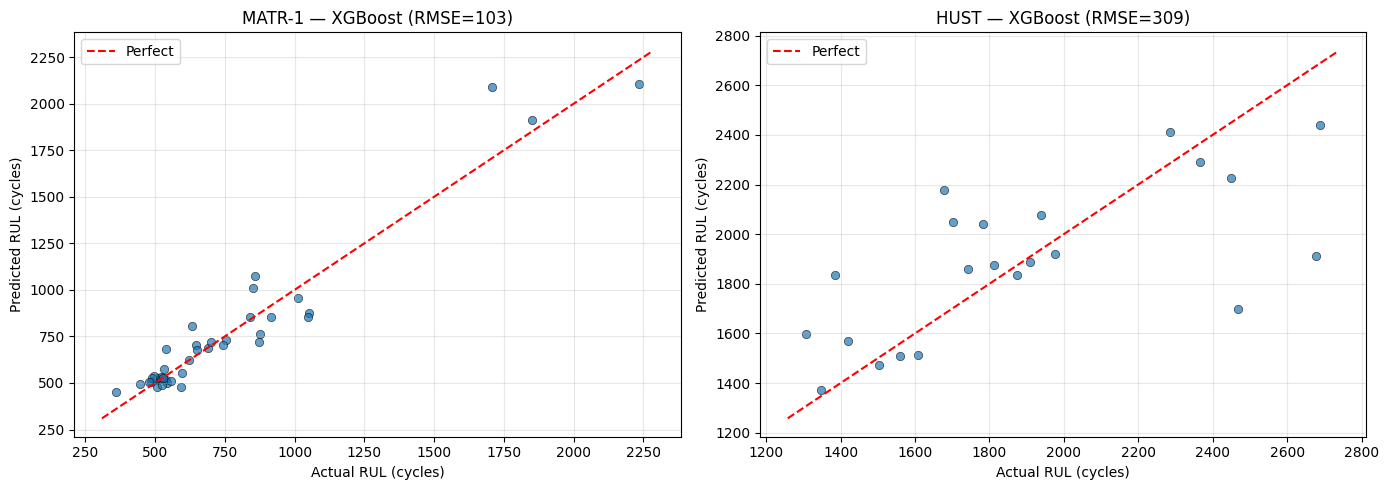

In [39]:
# --- Actual vs Predicted ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, yt, yp, rmse, title in [
    (axes[0], y_matr_test, matr_y_pred, matr_rmse, "MATR-1"),
    (axes[1], y_hust_test, hust_y_pred, hust_rmse, "HUST"),
]:
    ax.scatter(yt, yp, alpha=0.7, edgecolors='k', linewidth=0.5)
    lims = [min(yt.min(), yp.min())-50, max(yt.max(), yp.max())+50]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
    ax.set_xlabel("Actual RUL (cycles)"); ax.set_ylabel("Predicted RUL (cycles)")
    ax.set_title(f"{title} — XGBoost (RMSE={rmse:.0f})"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. SHAP Analysis — Global Feature Importance (Beeswarm Plot)

The **beeswarm plot** shows:
- Each dot = one battery cell
- X-axis = SHAP value (how much that feature pushed the prediction)
- Color = feature value (red = high, blue = low)
- Features sorted by overall importance (top = most important)


In [40]:
# --- Compute SHAP Values ---

feature_names = list(X_matr_train.columns)

matr_explainer = shap.TreeExplainer(matr_model)
matr_shap_values = matr_explainer.shap_values(matr_Xte_s)

hust_explainer = shap.TreeExplainer(hust_model)
hust_shap_values = hust_explainer.shap_values(hust_Xte_s)

print(f"MATR-1 SHAP shape: {matr_shap_values.shape}")
print(f"HUST SHAP shape:   {hust_shap_values.shape}")

MATR-1 SHAP shape: (42, 10)
HUST SHAP shape:   (22, 10)


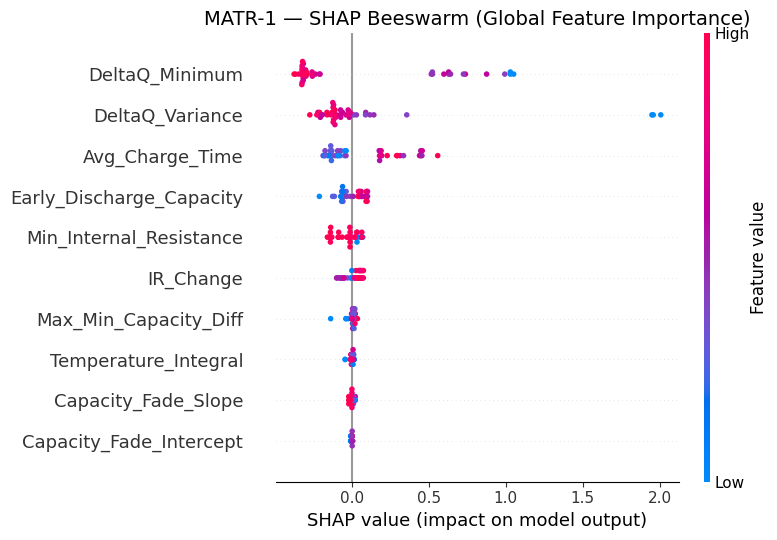

In [41]:
# --- Beeswarm Plot: MATR-1 ---
plt.figure(figsize=(10, 6))
plt.title("MATR-1 — SHAP Beeswarm (Global Feature Importance)", fontsize=14)
shap.summary_plot(matr_shap_values, matr_Xte_s, feature_names=feature_names, show=False)
plt.tight_layout(); plt.show()

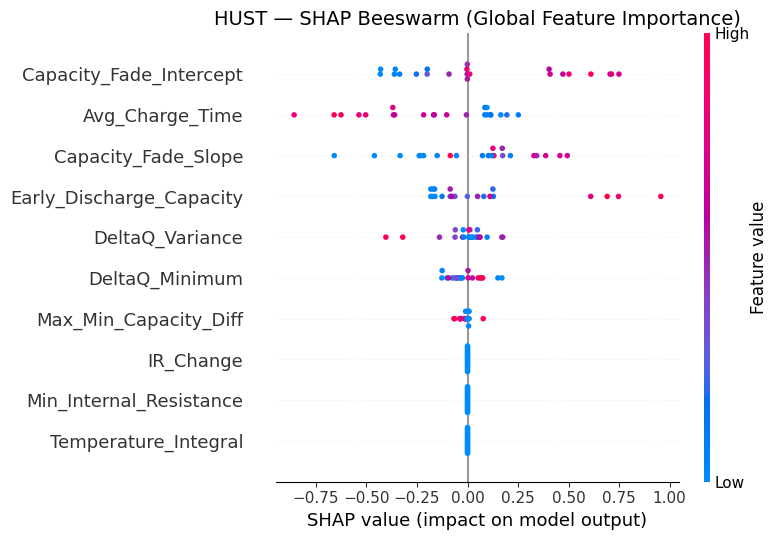

In [42]:
# --- Beeswarm Plot: HUST ---
plt.figure(figsize=(10, 6))
plt.title("HUST — SHAP Beeswarm (Global Feature Importance)", fontsize=14)
shap.summary_plot(hust_shap_values, hust_Xte_s, feature_names=feature_names, show=False)
plt.tight_layout(); plt.show()

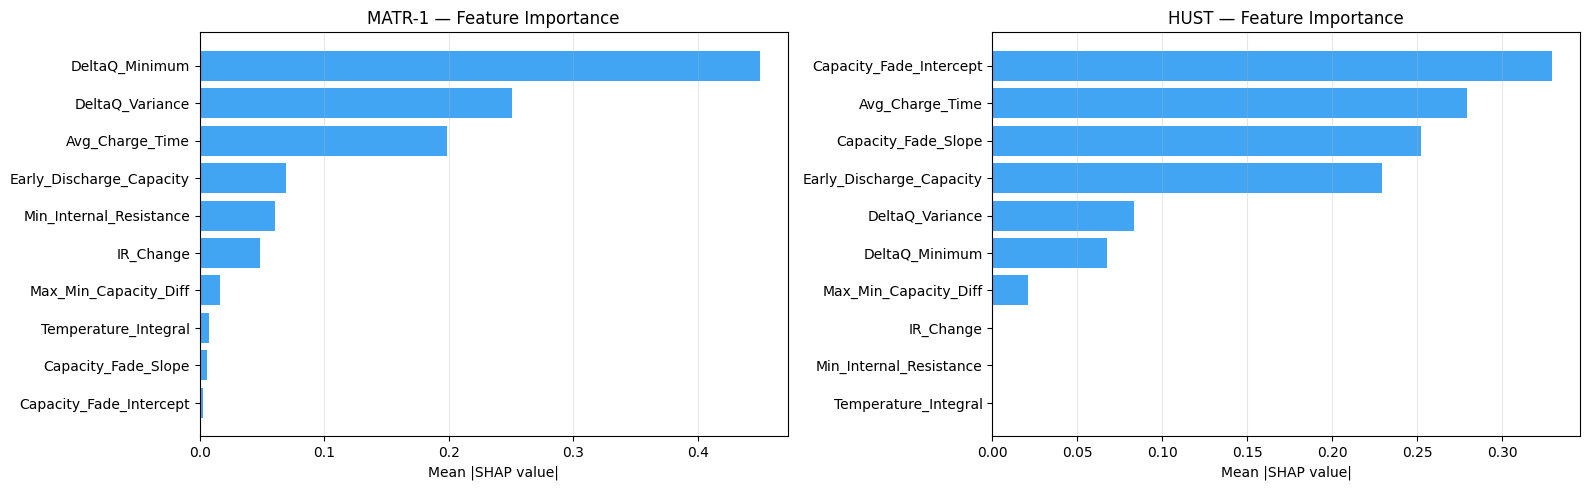

In [43]:
# --- Bar Plot: Mean |SHAP| (both datasets side by side) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, sv, title in [(axes[0], matr_shap_values, "MATR-1"), (axes[1], hust_shap_values, "HUST")]:
    mean_abs = np.abs(sv).mean(axis=0)
    idx = np.argsort(mean_abs)
    ax.barh(range(len(idx)), mean_abs[idx], color='#2196F3', alpha=0.85)
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([feature_names[i] for i in idx])
    ax.set_xlabel("Mean |SHAP value|"); ax.set_title(f"{title} — Feature Importance")
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

## 7. SHAP — Local Explanations (Force Plots)

A **force plot** explains ONE prediction:
- Red arrows = features pushing prediction **higher** (longer life)
- Blue arrows = features pushing it **lower** (shorter life)


Best:  MATR_b2c40 — Actual=529, Pred=529
Worst: MATR_b1c4 — Actual=1707, Pred=2091


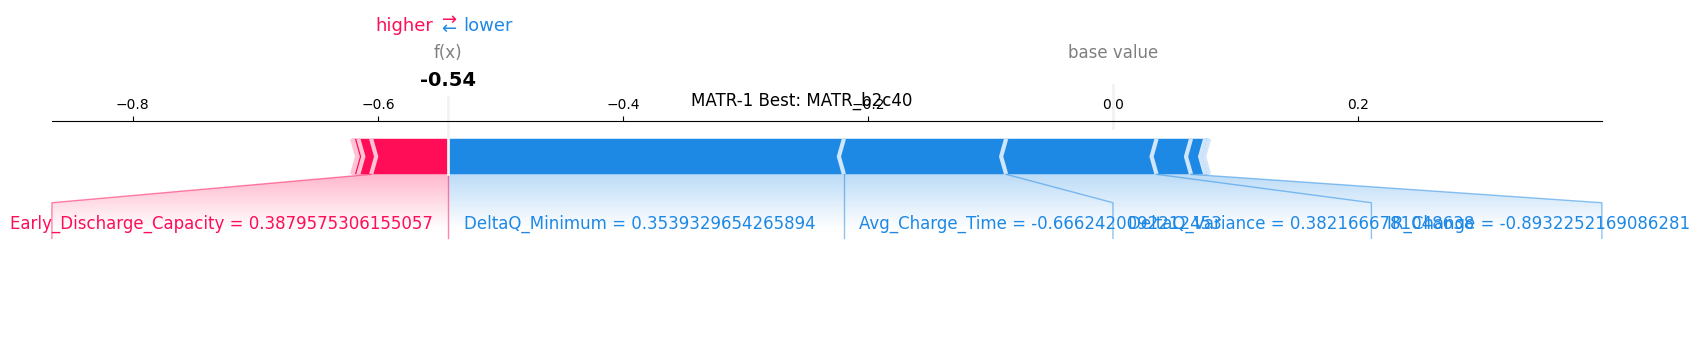

In [44]:
# --- Force Plot: MATR-1 (best and worst prediction) ---

matr_errors = np.abs(y_matr_test.values - matr_y_pred)
best_idx = np.argmin(matr_errors)
worst_idx = np.argmax(matr_errors)

print(f"Best:  {y_matr_test.index[best_idx]} — Actual={y_matr_test.values[best_idx]:.0f}, Pred={matr_y_pred[best_idx]:.0f}")
print(f"Worst: {y_matr_test.index[worst_idx]} — Actual={y_matr_test.values[worst_idx]:.0f}, Pred={matr_y_pred[worst_idx]:.0f}")

shap.force_plot(matr_explainer.expected_value, matr_shap_values[best_idx, :],
                matr_Xte_s[best_idx, :], feature_names=feature_names, matplotlib=True, show=False)
fig = plt.gcf()
fig.suptitle(f"MATR-1 Best: {y_matr_test.index[best_idx]}", fontsize=12)
plt.show()

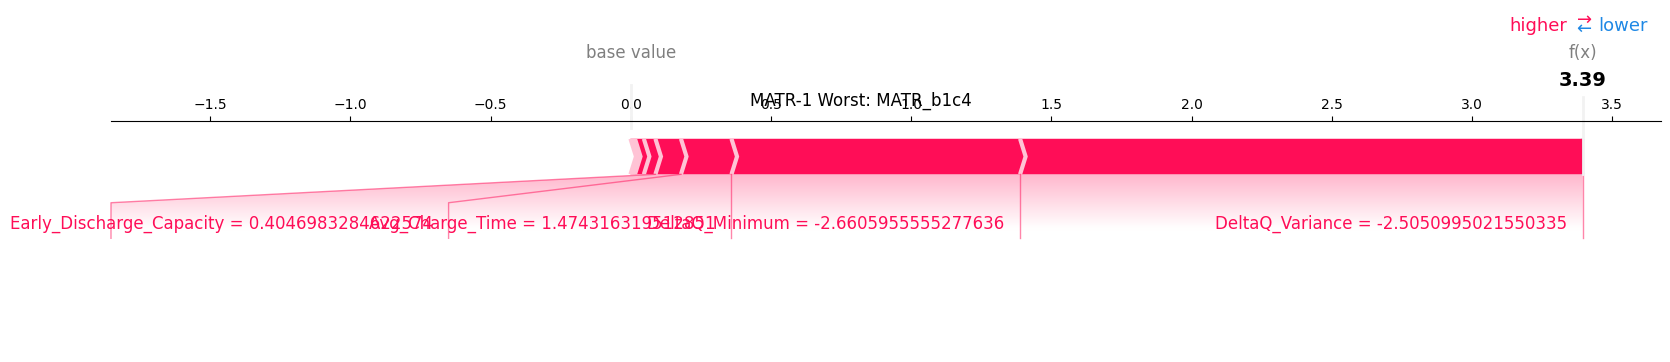

In [45]:
# --- Force Plot: MATR-1 (worst) ---
shap.force_plot(matr_explainer.expected_value, matr_shap_values[worst_idx, :],
                matr_Xte_s[worst_idx, :], feature_names=feature_names, matplotlib=True, show=False)
fig = plt.gcf()
fig.suptitle(f"MATR-1 Worst: {y_matr_test.index[worst_idx]}", fontsize=12)
plt.show()

HUST Best: HUST_6-2 — Actual=1908, Pred=1888


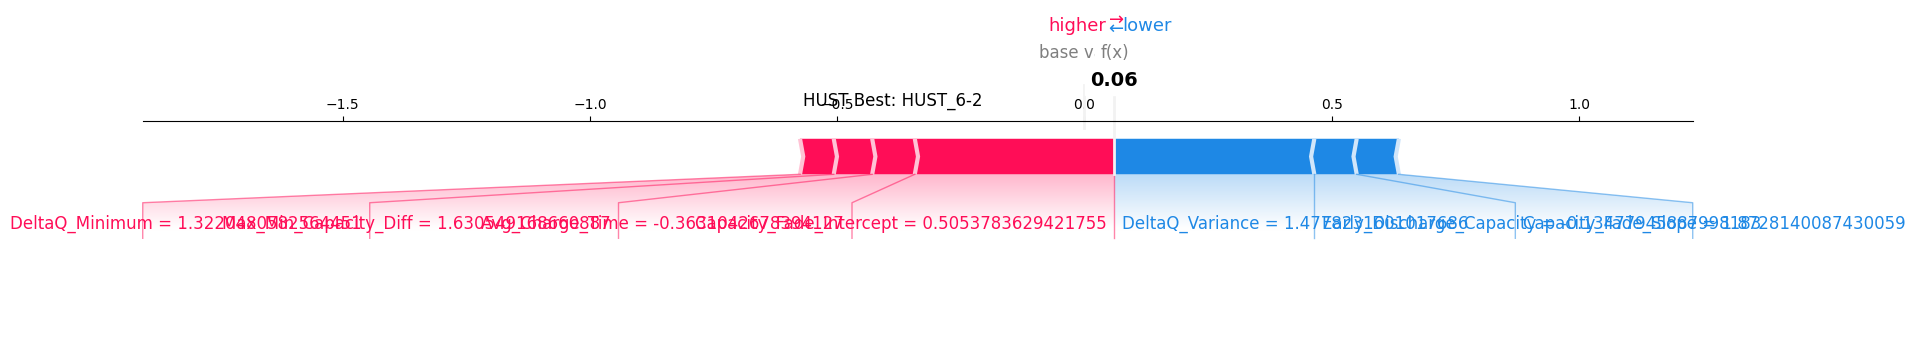

In [46]:
# --- Force Plot: HUST (best) ---
hust_errors = np.abs(y_hust_test.values - hust_y_pred)
best_h = np.argmin(hust_errors)

print(f"HUST Best: {y_hust_test.index[best_h]} — Actual={y_hust_test.values[best_h]:.0f}, Pred={hust_y_pred[best_h]:.0f}")

shap.force_plot(hust_explainer.expected_value, hust_shap_values[best_h, :],
                hust_Xte_s[best_h, :], feature_names=feature_names, matplotlib=True, show=False)
fig = plt.gcf()
fig.suptitle(f"HUST Best: {y_hust_test.index[best_h]}", fontsize=12)
plt.show()

## 8. SHAP Dependence Plots (Top 3 Features)

Shows how one feature's value relates to its SHAP impact.
Color = interaction with another feature (auto-detected).


MATR-1 Top 3:
  1. DeltaQ_Minimum (mean |SHAP| = 0.4497)
  2. DeltaQ_Variance (mean |SHAP| = 0.2507)
  3. Avg_Charge_Time (mean |SHAP| = 0.1990)


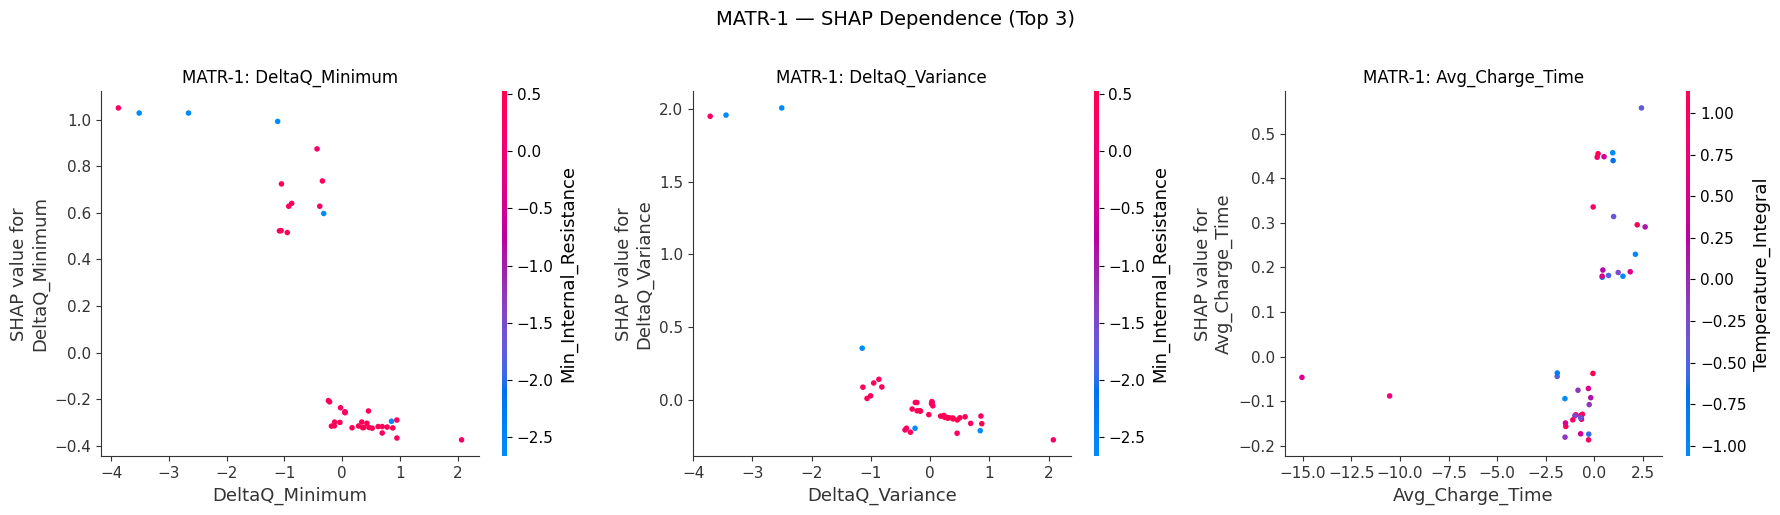

In [47]:
# --- Top 3 Features: MATR-1 ---
mean_abs_matr = np.abs(matr_shap_values).mean(axis=0)
top3_matr = np.argsort(mean_abs_matr)[-3:][::-1]

print("MATR-1 Top 3:")
for rank, idx in enumerate(top3_matr, 1):
    print(f"  {rank}. {feature_names[idx]} (mean |SHAP| = {mean_abs_matr[idx]:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat_idx in enumerate(top3_matr):
    plt.sca(axes[i])
    shap.dependence_plot(feat_idx, matr_shap_values, matr_Xte_s,
                          feature_names=feature_names, ax=axes[i], show=False)
    axes[i].set_title(f"MATR-1: {feature_names[feat_idx]}")
plt.suptitle("MATR-1 — SHAP Dependence (Top 3)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

HUST Top 3:
  1. Capacity_Fade_Intercept (mean |SHAP| = 0.3292)
  2. Avg_Charge_Time (mean |SHAP| = 0.2794)
  3. Capacity_Fade_Slope (mean |SHAP| = 0.2524)


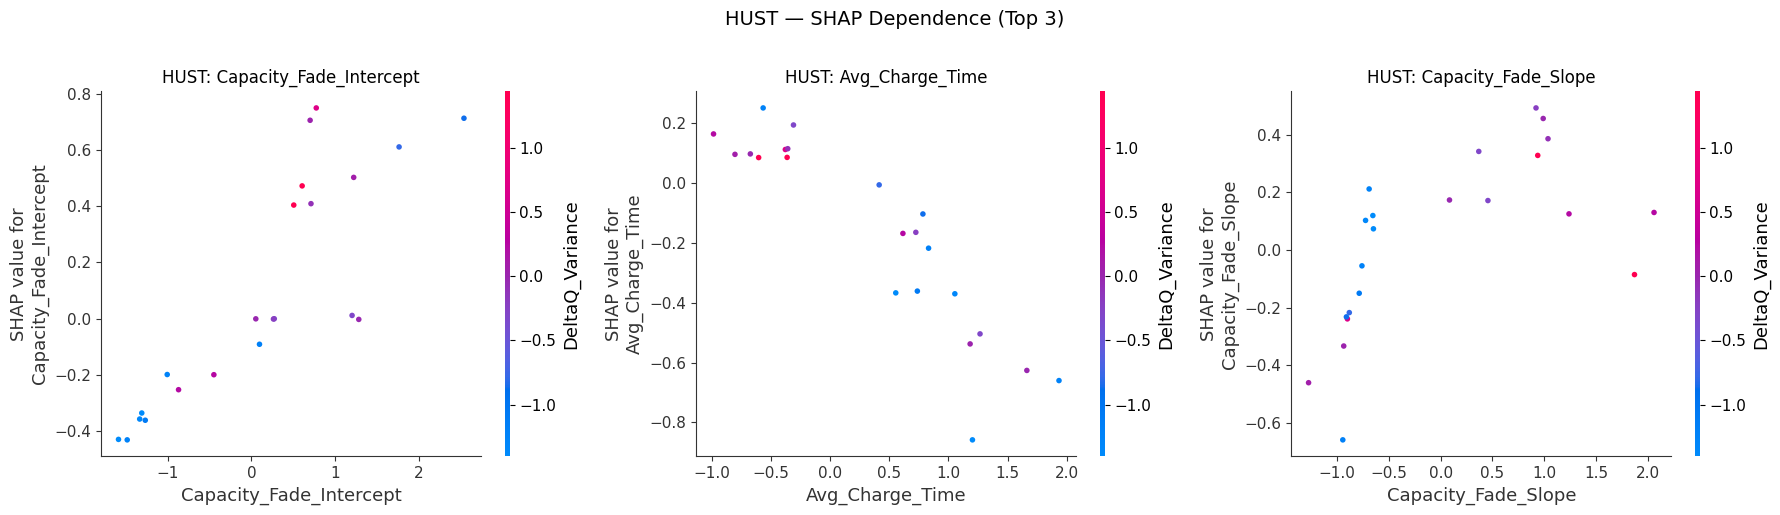

In [48]:
# --- Top 3 Features: HUST ---
mean_abs_hust = np.abs(hust_shap_values).mean(axis=0)
top3_hust = np.argsort(mean_abs_hust)[-3:][::-1]

print("HUST Top 3:")
for rank, idx in enumerate(top3_hust, 1):
    print(f"  {rank}. {feature_names[idx]} (mean |SHAP| = {mean_abs_hust[idx]:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat_idx in enumerate(top3_hust):
    plt.sca(axes[i])
    shap.dependence_plot(feat_idx, hust_shap_values, hust_Xte_s,
                          feature_names=feature_names, ax=axes[i], show=False)
    axes[i].set_title(f"HUST: {feature_names[feat_idx]}")
plt.suptitle("HUST — SHAP Dependence (Top 3)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 9. SHAP Waterfall Plot


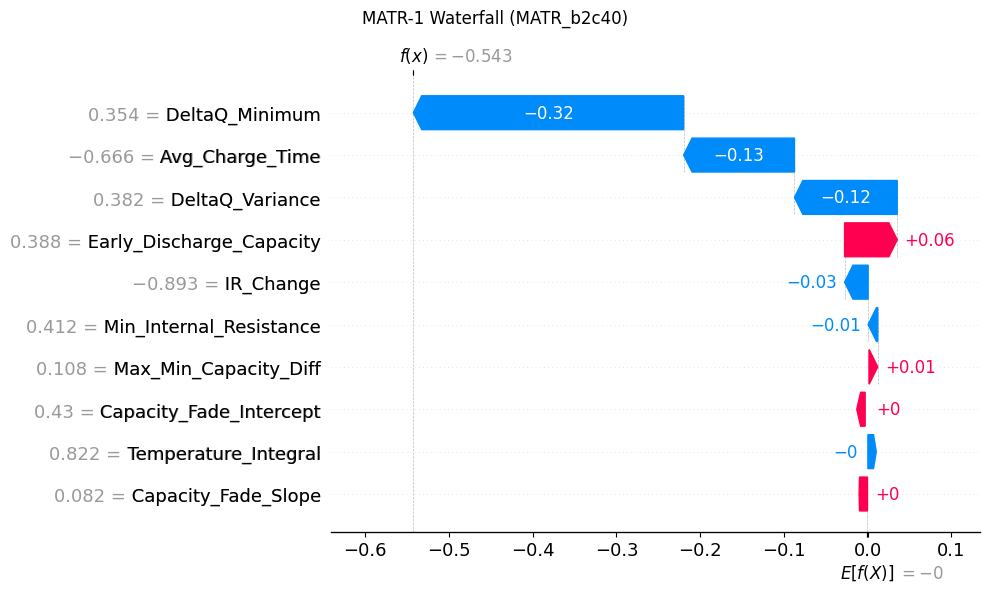

In [49]:
# --- Waterfall: MATR-1 (best predicted cell) ---
exp_matr = shap.Explanation(values=matr_shap_values[best_idx],
                             base_values=matr_explainer.expected_value,
                             data=matr_Xte_s[best_idx],
                             feature_names=feature_names)
shap.plots.waterfall(exp_matr, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)
fig.suptitle(f"MATR-1 Waterfall ({y_matr_test.index[best_idx]})", fontsize=12)
plt.tight_layout()
plt.show()

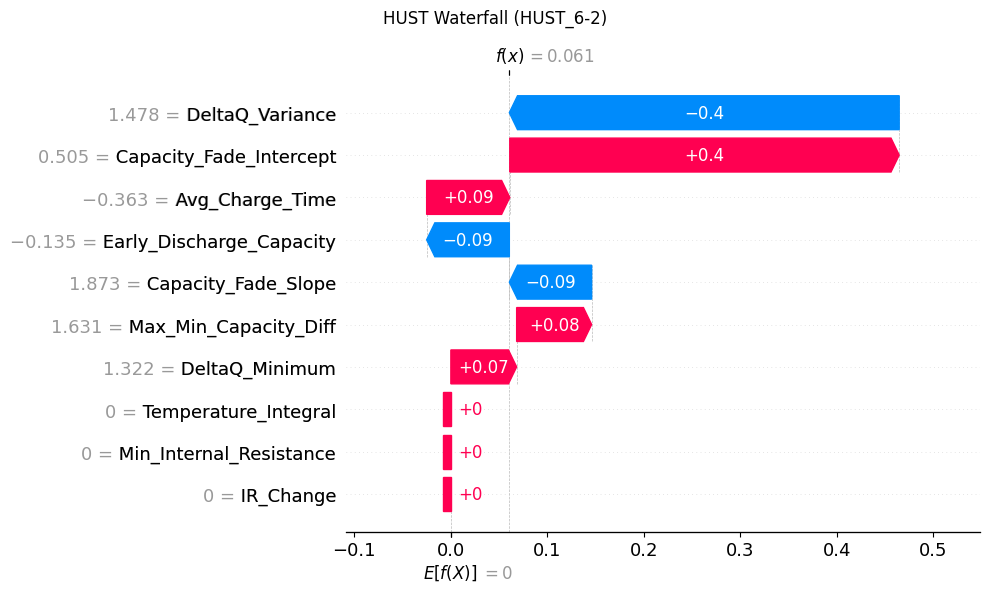

In [50]:
# --- Waterfall: HUST (best predicted cell) ---
exp_hust = shap.Explanation(values=hust_shap_values[best_h],
                             base_values=hust_explainer.expected_value,
                             data=hust_Xte_s[best_h],
                             feature_names=feature_names)
shap.plots.waterfall(exp_hust, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)
fig.suptitle(f"HUST Waterfall ({y_hust_test.index[best_h]})", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Electrochemical Interpretation

### What the SHAP Analysis Tells Us

1. **DeltaQ_Variance** — Measures non-uniform degradation across voltage levels.
   High variance = non-uniform degradation = shorter life.
   *Mechanism*: Lithium plating, SEI growth at specific potentials.

2. **DeltaQ_Minimum** — Worst-case capacity loss at any voltage point.
   Large negative = severe localized degradation.
   *Mechanism*: Loss of active material at specific electrode potentials.

3. **Capacity_Fade_Slope** — Rate of early capacity loss.
   More negative = faster degradation = shorter life.
   *Mechanism*: Accelerating SEI growth, lithium inventory loss.

4. **Early_Discharge_Capacity** — Initial capacity (cycle 2).
   Does NOT always predict lifetime (depends on charging protocol).

5. **IR_Change / Min_Internal_Resistance** — Rising resistance = electrode degradation.
   *Mechanism*: SEI thickening, contact loss, electrolyte decomposition.

6. **Temperature_Integral** — Cumulative thermal stress.
   *Mechanism*: Arrhenius-type acceleration of side reactions.

### Why This Matters:
- SHAP makes XGBoost **transparent** — we verify it learned real physics
- If a model relied on unexpected features, it might be overfitting
- Domain experts can validate the model's reasoning aligns with electrochemistry


## 11. Summary


In [51]:
# --- Final Summary ---
print("=" * 60)
print("  SHAP Analysis Summary")
print("=" * 60)

for name, sv, rmse in [("MATR-1", matr_shap_values, matr_rmse),
                         ("HUST", hust_shap_values, hust_rmse)]:
    mean_abs = np.abs(sv).mean(axis=0)
    top = np.argsort(mean_abs)[::-1]
    print(f"\n{name} (XGBoost RMSE = {rmse:.0f} cycles)")
    print("-" * 40)
    for rank, idx in enumerate(top[:5], 1):
        print(f"  {rank}. {feature_names[idx]:30s} |SHAP| = {mean_abs[idx]:.4f}")

print("\n" + "=" * 60)
print("All SHAP plots generated successfully!")
print("=" * 60)

  SHAP Analysis Summary

MATR-1 (XGBoost RMSE = 103 cycles)
----------------------------------------
  1. DeltaQ_Minimum                 |SHAP| = 0.4497
  2. DeltaQ_Variance                |SHAP| = 0.2507
  3. Avg_Charge_Time                |SHAP| = 0.1990
  4. Early_Discharge_Capacity       |SHAP| = 0.0697
  5. Min_Internal_Resistance        |SHAP| = 0.0607

HUST (XGBoost RMSE = 309 cycles)
----------------------------------------
  1. Capacity_Fade_Intercept        |SHAP| = 0.3292
  2. Avg_Charge_Time                |SHAP| = 0.2794
  3. Capacity_Fade_Slope            |SHAP| = 0.2524
  4. Early_Discharge_Capacity       |SHAP| = 0.2291
  5. DeltaQ_Variance                |SHAP| = 0.0834

All SHAP plots generated successfully!
